# 分析思路说明

基于分类值1和3在每行出现的次数（分子），以及按该行 非 NaN 数据总量（分母） 计算得到的每个被试人的分类频率值分布。
然后用统计检验的方法检查两组答案分布存在显著差异

# 数据预处理

## 读取数据&查看数据基本信息

In [13]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt

# 读取数据
df = pd.read_csv('Z:/李玲珑_data/玲珑 at UCSD/20260306/coded_ideas_RA_semantic_精简.csv')

# 查看数据基本信息
print("数据形状:", df.shape)
print("\n前5行数据:")
print(df.head())
print("\n数据类型:")
print(df.dtypes)


数据形状: (343, 41)

前5行数据:
   synthetic_id  category_1  category_2  category_3  category_4  category_5  \
0             1         1.0         3.0         1.0         NaN         NaN   
1             2         NaN         NaN         NaN         NaN         NaN   
2             3         1.0         NaN         NaN         NaN         NaN   
3             4         NaN         NaN         NaN         NaN         NaN   
4             5         3.0         NaN         NaN         NaN         NaN   

   category_6  category_7  category_8  category_9  ...  category_31  \
0         NaN         NaN         NaN         NaN  ...          NaN   
1         NaN         NaN         NaN         NaN  ...          NaN   
2         NaN         NaN         NaN         NaN  ...          NaN   
3         NaN         NaN         NaN         NaN  ...          NaN   
4         NaN         NaN         NaN         NaN  ...          NaN   

   category_32  category_33  category_34  category_35  category_36  \
0   

## 分离两组数据

In [14]:
# 分离两组数据
group1 = df.iloc[:, 1:21]  # category_1 到 category_20
group2 = df.iloc[:, 21:41]  # category_21 到 category_40

print("第一组 (category_1-20):")
print(f"列数: {group1.shape[1]}")
print(f"非空值数量: {group1.notna().sum().sum()}")
print(f"类别分布:\n{group1.stack().value_counts().sort_index()}")

print("\n" + "="*50)
print("第二组 (category_21-40):")
print(f"列数: {group2.shape[1]}")
print(f"非空值数量: {group2.notna().sum().sum()}")
print(f"类别分布:\n{group2.stack().value_counts().sort_index()}")


第一组 (category_1-20):
列数: 20
非空值数量: 547
类别分布:
1.0    344
2.0     23
3.0    179
4.0      1
Name: count, dtype: int64

第二组 (category_21-40):
列数: 20
非空值数量: 600
类别分布:
1.0    314
2.0     33
3.0    231
4.0     22
Name: count, dtype: int64


## 清洗数据

In [15]:
## 用NaN代替每个cell中不是 1.0, 2.0, 3.0 的数据， 然后删除只有NaN数据的行

# 定义允许的值，因为值是 4.0 的源数据是乱填，无效回答，所以也清除
allowed_values = [1.0, 2.0, 3.0]

# --- 第一步：对所有列执行替换 ---
# 注意：非数字列（如字符串 'A'）因为不在 allowed_values 中，也会变成 NaN
group1 = group1.where(group1.isin(allowed_values), np.nan)
group2 = group2.where(group2.isin(allowed_values), np.nan)
                      
# --- 第二步：删除所有列全为 NaN 的行 ---

# how='all' 表示只有当一行中所有列都是 NaN 时才删除
group1 = group1.dropna(how='all').reset_index(drop=True)
group2 = group2.dropna(how='all').reset_index(drop=True)

## 保存数据

In [17]:
group1.to_csv('Z:/李玲珑_data/玲珑 at UCSD/20260306/group1_v1.csv', index=False)
group2.to_csv('Z:/李玲珑_data/玲珑 at UCSD/20260306/group2_v1.csv', index=False)

# chatgpt的方案

## 分项检验

### 数据处理

In [12]:
import pandas as pd
import numpy as np

from scipy.stats import mannwhitneyu
import statsmodels.formula.api as smf

# ==============================
# 1 加载数据
# ==============================

g1 = group1.copy()
g2 = group2.copy()
# g1 = pd.read_csv("Z:/李玲珑_data/玲珑 at UCSD/20260306/group1_v1.csv")
# g2 = pd.read_csv("Z:/李玲珑_data/玲珑 at UCSD/20260306/group2_v1.csv")

g1["group"] = "Group1"
g2["group"] = "Group2"

df = pd.concat([g1, g2], ignore_index=True)

df["participant"] = np.arange(len(df))

print("---Group sizes: ---")
print(df["group"].value_counts())

# ==============================
# 2 转换 long format
# ==============================

long = df.melt(
    id_vars=["participant", "group"],
    var_name="question",
    value_name="response"
)

long = long.dropna() # 如果不加参数，dropna() 会检查每一行。只要某一行里 任意一个列 存在空值，这一整行就会被删除。

print("\n ---Total valid responses:---")
print(long.shape[0])

print("\n ---head 5 line of dataframe long--- ")
print(long.head(5))

print("\n ---显示 participant 列值为 1 的行--- ")
print(long[long['participant'] == 2])

# ==============================
# 3 计算每人频率
# ==============================

# 这段代码对之前转换得到的长格式 DataFrame long进行统计，计算每个参与者在不同问题上各类回答选项的频率（百分比）.
freq = (
    long.groupby(["participant","group"])["response"]
    .value_counts(normalize=True)   # 统计每个参与者在每个组内各种回答（response 值）的出现次数，并将次数转为频率（百分比）
    .unstack(fill_value=0)          # 将上一步得到的、以不同回答（response 值）为索引的多级 Series 转换为一个 DataFrame。每一列对应一个独特的回答（response 值），填充该参与者在该回答上的频率。如果某个回答从未出现，则用 0 填充（fill_value=0）。
    .reset_index()
)

# 通过 .rename()方法，有选择地重命名了 freqDataFrame 中的两列
freq = freq.rename(columns={   
    1: "freq_1",
    3: "freq_3"
})

print("\nFrequency table head:")
print(freq.head())
print("\nFrequency table tail:")
print(freq.tail())

# ==============================
# 4 描述统计
# ==============================

desc = freq.groupby("group")[["freq_1","freq_3"]].describe()

print("\nDescriptive statistics")
print(desc)

---Group sizes: ---
group
Group1    170
Group2    169
Name: count, dtype: int64

 ---Total valid responses:---
1124

 ---head 5 line of dataframe long--- 
   participant   group    question  response
0            0  Group1  category_1       1.0
1            1  Group1  category_1       1.0
2            2  Group1  category_1       3.0
3            3  Group1  category_1       1.0
4            4  Group1  category_1       2.0

 ---显示 participant 列值为 1 的行--- 
   participant   group    question  response
2            2  Group1  category_1       3.0

Frequency table head:
response  participant   group    freq_1       2.0    freq_3
0                   0  Group1  0.666667  0.000000  0.333333
1                   1  Group1  1.000000  0.000000  0.000000
2                   2  Group1  0.000000  0.000000  1.000000
3                   3  Group1  0.875000  0.000000  0.125000
4                   4  Group1  0.000000  0.333333  0.666667

Frequency table tail:
response  participant   group    freq_1  2.0  

### Mann–Whitney U test 

In [31]:
# ==============================
# 5 Mann–Whitney U test
# ==============================

g1_f1 = freq[freq.group=="Group1"]["freq_1"]
g2_f1 = freq[freq.group=="Group2"]["freq_1"]

g1_f3 = freq[freq.group=="Group1"]["freq_3"]
g2_f3 = freq[freq.group=="Group2"]["freq_3"]

u1, p1 = mannwhitneyu(g1_f1, g2_f1, alternative="two-sided")
u3, p3 = mannwhitneyu(g1_f3, g2_f3, alternative="two-sided")

print("\nMann-Whitney U test")
print("freq_1: U =", u1, "p =", p1)
print("freq_3: U =", u3, "p =", p3)


Mann-Whitney U test
freq_1: U = 15621.5 p = 0.1573123116682763
freq_3: U = 13378.5 p = 0.2639916746803165


### logistic regression

In [37]:
# ==============================
# 6 logistic regression
# ==============================

long["is1"] = (long["response"] == 1).astype(int)

model = smf.logit("is1 ~ group", data=long).fit()

print("\nLogistic regression result")
print(model.summary())

# Odds ratio
odds_ratio = np.exp(model.params)

print("\nOdds Ratio")
print(odds_ratio)

Optimization terminated successfully.
         Current function value: 0.674602
         Iterations 4

Logistic regression result
                           Logit Regression Results                           
Dep. Variable:                    is1   No. Observations:                 1124
Model:                          Logit   Df Residuals:                     1122
Method:                           MLE   Df Model:                            1
Date:                Thu, 12 Mar 2026   Pseudo R-squ.:                0.005724
Time:                        17:45:37   Log-Likelihood:                -758.25
converged:                       True   LL-Null:                       -762.62
Covariance Type:            nonrobust   LLR p-value:                  0.003129
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept           0.5324      0.089      6.006      0.000       0.35

### 整体类别分布

In [38]:
# ==============================
# 7 整体类别分布
# ==============================

overall = long.groupby(["group","response"]).size().unstack(fill_value=0)

print("\nOverall category counts")
print(overall)

print("\nOverall category proportions")

prop = overall.div(overall.sum(axis=1), axis=0)

print(prop)


Overall category counts
response  1.0  2.0  3.0
group                  
Group1    344   23  179
Group2    314   33  231

Overall category proportions
response       1.0       2.0       3.0
group                                 
Group1    0.630037  0.042125  0.327839
Group2    0.543253  0.057093  0.399654


## 使用 Generalized Linear Mixed Model 分析

**这个模型对应的统计模型**

$$
\text{logit}(P(is1)) =
\beta_0 + \beta_1 \cdot group +
u_{participant}
$$

其中

```
u_participant ~ N(0, σ²)
```

也就是论文中常写的：

```
is1 ~ group + (1 | participant)
```

---

**输出结果如何解释**

关键是这一行：

```
group[T.Group2]
```

假设输出：

```
coef = -0.24
```

计算 **Odds Ratio**

```
exp(-0.24) = 0.79
```

解释：

```
Group2 选择1的概率 ≈ Group1 的 0.79 倍
```

In [48]:
# ==============================
# 8 GLMM (Generalized Linear Mixed Model)
# ==============================

import numpy as np
from statsmodels.genmod.bayes_mixed_glm import BinomialBayesMixedGLM

print("\nRunning GLMM (logistic mixed model)")

# 响应变量
long["is1"] = (long["response"] == 1).astype(int)

# participant 转换为分类变量
long["participant"] = long["participant"].astype("category")

# GLMM模型
model = BinomialBayesMixedGLM.from_formula(
    "is1 ~ group",
    {"participant": "0 + C(participant)"},
    long
)

result = model.fit_vb()

print("\nGLMM result")
print(result.summary())

# Odds ratio
# odds_ratio = np.exp(result.params)

print("\nGLMM Odds Ratios")
# print(odds_ratio)

fe = result.params[:2]

print("fixed effects: ", fe)
print("Odds ratios (fixed effects)")
print(np.exp(fe))


Running GLMM (logistic mixed model)

GLMM result
                  Binomial Mixed GLM Results
                Type Post. Mean Post. SD   SD  SD (LB) SD (UB)
--------------------------------------------------------------
Intercept          M     0.5800   0.0656                      
group[T.Group2]    M    -0.3339   0.0905                      
participant        V    -0.0916   0.0384 0.912   0.845   0.985
Parameter types are mean structure (M) and variance structure
(V)
Variance parameters are modeled as log standard deviations

GLMM Odds Ratios
fixed effects:  [ 0.58004189 -0.333921  ]
Odds ratios (fixed effects)
[1.78611326 0.71611035]



**一、GLMM模型结果解读**

你得到的核心输出是：

```
Binomial Mixed GLM Results
==============================================================
                Type Post. Mean Post. SD
--------------------------------------------------------------
Intercept          M     0.5800
group[T.Group2]    M    -0.3339
participant        V    -0.0916
==============================================================
```

模型：

$$
\text{logit}(P(\text{response}=1)) = \beta_0 + \beta_1 \cdot group + u_{participant}
$$

其中

```
u_participant ~ N(0, σ²)
```

---

**二、固定效应（最重要）**

group[T.Group2]

```
coef = -0.3339
```

含义：

```
Group2 相对于 Group1 的 log-odds 变化
```

计算 **Odds Ratio**

$$
OR = e^{-0.3339}
$$

结果：

```
OR ≈ 0.716
```

解释：

```
Group2 选择 1 的概率 ≈ Group1 的 0.72 倍
```

也就是说：

**Group2 更不倾向选择 1。**

---

**三、Intercept**

```
Intercept = 0.580
```

对应的 baseline 概率：

$$
p = \frac{1}{1+e^{-0.58}}
$$

结果：

```
p ≈ 0.64
```

解释：

```
Group1 选择 1 的平均概率 ≈ 64%
```

与你数据的整体比例非常接近。

---

**四、随机效应**

```
participant V = -0.0916
```

注意：

```
Variance parameters are modeled as log standard deviations
```

所以：

```math
SD = e^{-0.0916}
```

结果：

```
SD ≈ 0.91
```

解释：

```
不同 participant 之间存在较大差异
```

也就是：

```
个体差异明显
```

---


**五、统计结论**

综合 GLMM：

| 结果                  | 解释            |
| ------------------- | ------------- |
| Intercept OR=1.79   | Group1选择1概率较高 |
| Group2 OR=0.72      | Group2更少选择1   |
| participant SD≈0.91 | 个体差异明显        |

---

**六、结合之前所有统计**

完整结论：

| 分析                  | 结果         |
| ------------------- | ---------- |
| Mann-Whitney        | 不显著        |
| Logistic regression | Group2更少选1 |
| GLMM                | Group2更少选1 |

解释：

```
participant-level variation 较大
```

但：

```
总体回答层面存在差异
```



#### 基于GLMM得到P值和CI

In [52]:
import numpy as np
from scipy.stats import norm

# 响应变量
long["is1"] = (long["response"] == 1).astype(int)

# participant 转换为分类变量
long["participant"] = long["participant"].astype("category")

# GLMM模型
model = BinomialBayesMixedGLM.from_formula(
    "is1 ~ group",
    {"participant": "0 + C(participant)"},
    long
)

result = model.fit_vb()

print("\nGLMM result")
print(result.summary())


# ==============================
# 固定效应
# ==============================

fe = result.fe_mean
se = result.fe_sd

names = result.model.exog_names


# ==============================
# 计算统计量
# ==============================

z = fe / se
p = 2 * (1 - norm.cdf(np.abs(z)))

ci_low = fe - 1.96 * se
ci_high = fe + 1.96 * se

# Odds ratio
or_val = np.exp(fe)
or_low = np.exp(ci_low)
or_high = np.exp(ci_high)


# ==============================
# 输出结果
# ==============================

print("\nGLMM fixed effects results\n")

for i in range(len(names)):

    print(names[i])
    print("beta =", fe[i])
    print("SE =", se[i])
    print("z =", z[i])
    print("p =", p[i])

    print("95% CI (log-odds) =", ci_low[i], ",", ci_high[i])

    print("Odds Ratio =", or_val[i])
    print("OR 95% CI =", or_low[i], ",", or_high[i])

    print()


GLMM result
                  Binomial Mixed GLM Results
                Type Post. Mean Post. SD   SD  SD (LB) SD (UB)
--------------------------------------------------------------
Intercept          M     0.5800   0.0656                      
group[T.Group2]    M    -0.3339   0.0905                      
participant        V    -0.0916   0.0384 0.912   0.845   0.985
Parameter types are mean structure (M) and variance structure
(V)
Variance parameters are modeled as log standard deviations

GLMM fixed effects results

Intercept
beta = 0.5800418917242707
SE = 0.06556709322880243
z = 8.846539676544161
p = 0.0
95% CI (log-odds) = 0.4515303889958179 , 0.7085533944527235
Odds Ratio = 1.7861132525467474
OR 95% CI = 1.5707141507026132 , 2.0310510028168256

group[T.Group2]
beta = -0.33392101954330194
SE = 0.09048612977745092
z = -3.690300605900318
p = 0.00022398920307087344
95% CI (log-odds) = -0.5112738339071057 , -0.15656820517949815
Odds Ratio = 0.7161103387153483
OR 95% CI = 0.599731134

In [53]:
names

['Intercept', 'group[T.Group2]']

## 卡方检验

In [36]:
# ==============================
# 9 Chi-square test
# ==============================

from scipy.stats import chi2_contingency
import numpy as np

print("\nChi-square test (Group × Response)")

# 构造列联表
table = (
    long.groupby(["group", "response"])
    .size()
    .unstack(fill_value=0)
)

print("\nContingency table")
print(table)

# 卡方检验
chi2, p, dof, expected = chi2_contingency(table)

print("\nChi-square test result")
print("Chi2 =", chi2)
print("df =", dof)
print("p =", p)

# ==============================
# 计算 Cramer's V (效应量)
# ==============================

n = table.values.sum()

r, c = table.shape

cramers_v = np.sqrt(chi2 / (n * (min(r, c) - 1)))

print("\nEffect size (Cramer's V)")
print(cramers_v)

# ==============================
# 期望频数
# ==============================

print("\nExpected frequencies")
print(expected)


Chi-square test (Group × Response)

Contingency table
response  1.0  2.0  3.0
group                  
Group1    344   23  179
Group2    314   33  231

Chi-square test result
Chi2 = 8.844754273111574
df = 2
p = 0.012005659245701706

Effect size (Cramer's V)
0.08870737547477323

Expected frequencies
[[319.63345196  27.20284698 199.16370107]
 [338.36654804  28.79715302 210.83629893]]


**结论**：
- p < 0.05，两组的回答分布存在显著差异 
- Cramer's V = 0.0887，差异显著但效应较小 

### stacked bar plot

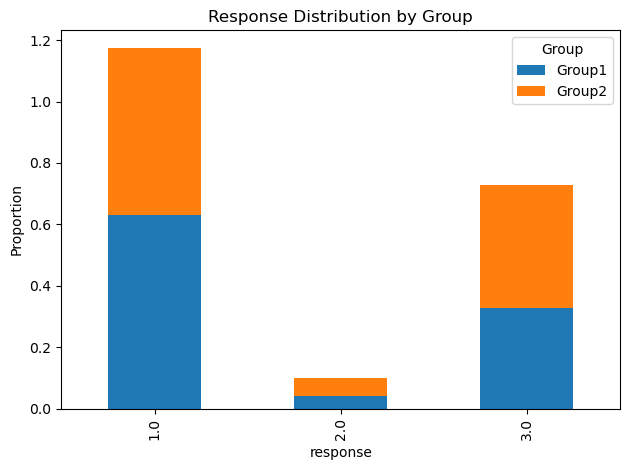

In [37]:
import matplotlib.pyplot as plt

prop = table.div(table.sum(axis=1), axis=0)

prop.T.plot(kind="bar", stacked=True)

plt.ylabel("Proportion")
plt.title("Response Distribution by Group")

plt.legend(title="Group")

plt.tight_layout()

plt.show()

## all-in-one


Loading data...
Group sizes:
group
Group1    170
Group2    169
Name: count, dtype: int64

Reshaping to long format...
Total valid responses: 1124

Computing participant frequencies...
response  participant   group    freq_1       2.0    freq_3
0                   0  Group1  0.666667  0.000000  0.333333
1                   1  Group1  1.000000  0.000000  0.000000
2                   2  Group1  0.000000  0.000000  1.000000
3                   3  Group1  0.875000  0.000000  0.125000
4                   4  Group1  0.000000  0.333333  0.666667

Descriptive statistics
response freq_1                                                        freq_3  \
          count      mean       std  min       25%       50%  75%  max  count   
group                                                                           
Group1    170.0  0.597000  0.366080  0.0  0.333333  0.666667  1.0  1.0  170.0   
Group2    169.0  0.545676  0.352091  0.0  0.333333  0.500000  0.8  1.0  169.0   

response                 

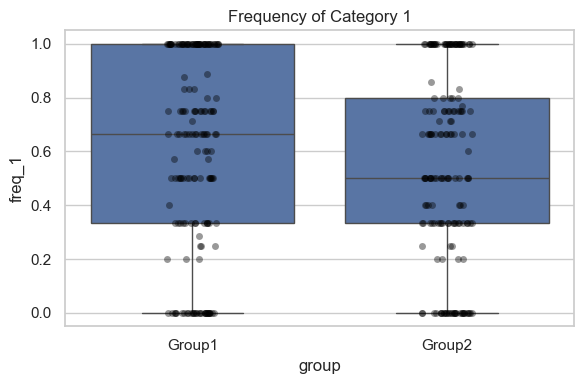

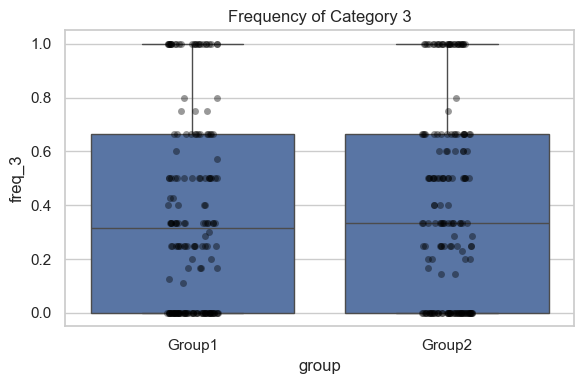

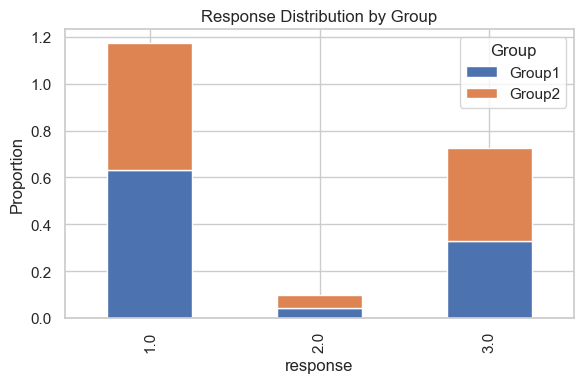


Analysis completed.
Figures saved:
freq1_boxplot.png
freq3_boxplot.png
response_distribution.png


In [49]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import mannwhitneyu
from scipy.stats import chi2_contingency

import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.genmod.bayes_mixed_glm import BinomialBayesMixedGLM


# =====================================================
# 1 读取数据
# =====================================================

print("\nLoading data...")

g1 = group1.copy()
g2 = group2.copy()
# g1 = pd.read_csv("Z:/李玲珑_data/玲珑 at UCSD/20260306/group1.csv")
# g2 = pd.read_csv("Z:/李玲珑_data/玲珑 at UCSD/20260306/group2.csv")

g1["group"] = "Group1"
g2["group"] = "Group2"

df = pd.concat([g1, g2], ignore_index=True)

df["participant"] = np.arange(len(df))

print("Group sizes:")
print(df["group"].value_counts())


# =====================================================
# 2 转换为 long format
# =====================================================

print("\nReshaping to long format...")

long = df.melt(
    id_vars=["participant", "group"],
    var_name="question",
    value_name="response"
)

long = long.dropna()

print("Total valid responses:", len(long))


# =====================================================
# 3 每个参与者频率
# =====================================================

print("\nComputing participant frequencies...")

freq = (
    long.groupby(["participant", "group"])["response"]
    .value_counts(normalize=True)
    .unstack(fill_value=0)
    .reset_index()
)

freq = freq.rename(columns={
    1: "freq_1",
    3: "freq_3"
})

print(freq.head())


# =====================================================
# 4 描述统计
# =====================================================

print("\nDescriptive statistics")

desc = freq.groupby("group")[["freq_1", "freq_3"]].describe()

print(desc)


# =====================================================
# 5 Mann-Whitney U test
# =====================================================

print("\nMann-Whitney U test")

g1_f1 = freq[freq.group == "Group1"]["freq_1"]
g2_f1 = freq[freq.group == "Group2"]["freq_1"]

g1_f3 = freq[freq.group == "Group1"]["freq_3"]
g2_f3 = freq[freq.group == "Group2"]["freq_3"]

u1, p1 = mannwhitneyu(g1_f1, g2_f1, alternative="two-sided")
u3, p3 = mannwhitneyu(g1_f3, g2_f3, alternative="two-sided")

print("freq_1: U =", u1, "p =", p1)
print("freq_3: U =", u3, "p =", p3)


# =====================================================
# 6 Logistic regression
# =====================================================

print("\nLogistic regression")

long["is1"] = (long["response"] == 1).astype(int)

logit_model = smf.logit("is1 ~ group", data=long).fit()

print(logit_model.summary())

odds_ratio = np.exp(logit_model.params)

print("\nOdds Ratios (logistic regression)")
print(odds_ratio)


# =====================================================
# 7 GLMM (Generalized Linear Mixed Model)
# =====================================================

print("\nRunning GLMM (logistic mixed model)")

long["participant"] = long["participant"].astype("category")

model_glmm = BinomialBayesMixedGLM.from_formula(
    "is1 ~ group",
    {"participant": "0 + C(participant)"},
    long
)

result_glmm = model_glmm.fit_vb()

print("\nGLMM result")
print(result_glmm.summary())

print("\nGLMM Odds Ratios (fixed effects)")

fixed_effects = result_glmm.params[:2]

print(np.exp(fixed_effects))


# =====================================================
# 8 Chi-square test
# =====================================================

print("\nChi-square test (Group × Response)")

table = (
    long.groupby(["group", "response"])
    .size()
    .unstack(fill_value=0)
)

print("\nContingency table")
print(table)

chi2, p, dof, expected = chi2_contingency(table)

print("\nChi-square test result")
print("Chi2 =", chi2)
print("df =", dof)
print("p =", p)


# =====================================================
# 9 Cramer's V
# =====================================================

print("\nEffect size (Cramer's V)")

n = table.values.sum()

r, c = table.shape

cramers_v = np.sqrt(chi2 / (n * (min(r, c) - 1)))

print(cramers_v)


# =====================================================
# 10 可视化
# =====================================================

sns.set(style="whitegrid")

# -----------------------------------------------------
# 箱线图 freq_1
# -----------------------------------------------------

plt.figure(figsize=(6, 4))

sns.boxplot(data=freq, x="group", y="freq_1")

sns.stripplot(
    data=freq,
    x="group",
    y="freq_1",
    color="black",
    alpha=0.4
)

plt.title("Frequency of Category 1")

plt.tight_layout()

plt.savefig("freq1_boxplot.png", dpi=300)

plt.show()


# -----------------------------------------------------
# 箱线图 freq_3
# -----------------------------------------------------

plt.figure(figsize=(6, 4))

sns.boxplot(data=freq, x="group", y="freq_3")

sns.stripplot(
    data=freq,
    x="group",
    y="freq_3",
    color="black",
    alpha=0.4
)

plt.title("Frequency of Category 3")

plt.tight_layout()

plt.savefig("freq3_boxplot.png", dpi=300)

plt.show()


# -----------------------------------------------------
# stacked bar plot
# -----------------------------------------------------

prop = table.div(table.sum(axis=1), axis=0)

prop.T.plot(
    kind="bar",
    stacked=True,
    figsize=(6, 4)
)

plt.ylabel("Proportion")

plt.title("Response Distribution by Group")

plt.legend(title="Group")

plt.tight_layout()

plt.savefig("response_distribution.png", dpi=300)

plt.show()


# =====================================================
# 11 完成
# =====================================================

print("\nAnalysis completed.")
print("Figures saved:")
print("freq1_boxplot.png")
print("freq3_boxplot.png")
print("response_distribution.png")

In [25]:
np.exp(0.58)/(1+np.exp(0.58))

np.float64(0.6410674063348171)

In [26]:
np.exp(0.58-0.3339)/(1+np.exp(0.58-0.3339))

np.float64(0.5612163463538256)

In [21]:
np.exp(0.2461)

np.float64(1.2790274698938033)